# 02 - Data Science de negocio: estadistica, ML y deep learning

Este notebook unifica la parte de Data Science del TFM.

La secuencia tiene sentido de negocio:

1. **Estadistica**: entender y justificar diferencias de margen, canales, costes y categorias.
2. **Machine Learning**: predecir unidades vendidas para anticipar demanda, stock y decisiones comerciales.
3. **Deep Learning opcional**: probar una red neuronal sencilla y decidir si aporta valor frente a modelos clasicos.

La idea no es meter tecnicas por rellenar, sino construir una historia defendible: primero entendemos el negocio, luego intentamos anticiparlo y finalmente comprobamos si la complejidad extra merece la pena.

## 0. Preparacion

Ejecuta esta celda antes de empezar. Carga librerias, helpers del proyecto y carpetas de salida.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from conexion_sql import read_sql
from eda_utils import asegurar_directorio
from estadistica_utils import detectar_outliers_iqr, resumen_por_grupo, matriz_correlacion, interpretar_pvalor
from modelos_utils import (
    crear_features_temporales,
    crear_lags_por_grupo,
    metricas_regresion,
    preparar_resultados_prediccion,
    train_test_temporal,
)
from visualizacion_utils import guardar_figura, grafico_real_vs_predicho

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

OUT_DATOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "datos")
OUT_GRAFICOS = asegurar_directorio(PROJECT_ROOT / "outputs" / "graficos")
OUT_CALIDAD = asegurar_directorio(PROJECT_ROOT / "outputs" / "informes_calidad")

PROJECT_ROOT

WindowsPath('G:/TFM_FINAL_VERSION_2')

# Parte A - Estadistica de negocio

Objetivo: comprobar con datos si las diferencias de margen y costes entre canales/categorias son relevantes para la toma de decisiones.

## 1. Carga de datos

Usamos la vista enriquecida porque ya contiene las dimensiones de negocio necesarias: producto, canal, cliente, promocion, pago, envio y margen.

In [2]:
ventas = read_sql("SELECT * FROM silver.ventas_limpias")
ventas["fecha"] = pd.to_datetime(ventas["fecha"])

ventas["descuento_pct_real"] = ventas["importe_descuento"] / (ventas["unidades_vendidas"] * ventas["precio_unitario_bruto"])
ventas["peso_comision_sobre_venta"] = ventas["comision"] / ventas["ventas_netas"].replace(0, np.nan)
ventas["peso_envio_sobre_venta"] = ventas["coste_envio_asignado"] / ventas["ventas_netas"].replace(0, np.nan)
ventas["peso_coste_producto_sobre_venta"] = ventas["coste_producto"] / ventas["ventas_netas"].replace(0, np.nan)
ventas = ventas.replace([np.inf, -np.inf], np.nan)

print(ventas.shape)
display(ventas.head())

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


(75000, 70)


,id_linea_venta,id_pedido,fecha,anio,mes_numero,mes_nombre,trimestre,semana_anio,dia_semana,dia_nombre,es_fin_de_semana,id_producto,codigo_producto,sku,producto,categoria,subcategoria,unidad_negocio,marca,segmento_marca,proveedor,pais_proveedor,id_cliente,codigo_cliente,segmento_cliente,pais_cliente,region_cliente,ciudad_cliente,canal_adquisicion,nivel_fidelidad,id_canal,canal,tipo_canal,comision_pct_defecto,tipo_fulfillment,ambito_pais,id_promocion,promocion,tipo_promocion,descuento_pct_promocion,id_metodo_pago,metodo_pago,fee_pago_pct,fee_pago_fijo,id_envio,tipo_envio,transportista,zona_envio,coste_envio_estimado,unidades_vendidas,precio_unitario_bruto,importe_descuento,ventas_netas,coste_producto,comision,coste_pago,coste_envio_asignado,costes_totales,margen,margen_pct,estado_margen,importe_bruto,descuento_pct_real,flag_margen_negativo,flag_margen_bajo,flag_descuento_superior_bruto,flag_registro_valido,peso_comision_sobre_venta,peso_envio_sobre_venta,peso_coste_producto_sobre_venta
0,1,ORD00063000,2025-07-26,2025,7,Julio,3,30,6,Sábado,True,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,Pantalones,Fashion,FitCore,Mid,Porto Home Supplies,PT,1,CUST000001,Recurrente,ES,Catalunya,Barcelona,Organic,Bronze,1,Web Propia,Direct,0.0000,Own,ES,7.0000,Spring Sale 2025,Seasonal,0.1200,1,Tarjeta,0.0125,0.3000,1,Standard,Correos,Nacional,3.5000,1,105.9900,12.7200,93.2700,55.4800,0.0000,1.4700,3.5000,60.4500,32.8200,0.3519,Margen alto,105.9900,0.1200,0,0,0,1,0.0000,0.0375,0.5948
1,2,ORD00003000,2025-09-11,2025,9,Septiembre,3,37,4,Jueves,False,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,Pantalones,Fashion,FitCore,Mid,Porto Home Supplies,PT,1,CUST000001,Recurrente,ES,Catalunya,Barcelona,Organic,Bronze,1,Web Propia,Direct,0.0000,Own,ES,6.0000,Rebajas Enero 2025,Seasonal,0.1800,1,Tarjeta,0.0125,0.3000,1,Standard,Correos,Nacional,3.5000,1,114.8300,20.6700,94.1600,55.4800,0.0000,1.4800,3.5000,60.4600,33.7000,0.3579,Margen alto,114.8300,0.1800,0,0,0,1,0.0000,0.0372,0.5892
2,3,ORD00006000,2025-05-22,2025,5,Mayo,2,21,4,Jueves,False,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,Pantalones,Fashion,FitCore,Mid,Porto Home Supplies,PT,1,CUST000001,Recurrente,ES,Catalunya,Barcelona,Organic,Bronze,1,Web Propia,Direct,0.0000,Own,ES,11.0000,Christmas Push 2025,Campaign,0.1000,1,Tarjeta,0.0125,0.3000,1,Standard,Correos,Nacional,3.5000,1,111.5100,11.1500,100.3600,55.4800,0.0000,1.5500,3.5000,60.5300,39.8300,0.3969,Margen alto,111.5100,0.1000,0,0,0,1,0.0000,0.0349,0.5528
3,4,ORD00015000,2024-06-20,2024,6,Junio,2,25,4,Jueves,False,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,Pantalones,Fashion,FitCore,Mid,Porto Home Supplies,PT,1,CUST000001,Recurrente,ES,Catalunya,Barcelona,Organic,Bronze,1,Web Propia,Direct,0.0000,Own,ES,4.0000,Black Friday 2024,Campaign,0.3000,1,Tarjeta,0.0125,0.3000,1,Standard,Correos,Nacional,3.5000,1,115.9300,34.7800,81.1500,55.4800,0.0000,1.3100,3.5000,60.2900,20.8600,0.2571,Margen alto,115.9300,0.3000,0,0,0,1,0.0000,0.0431,0.6837
4,5,ORD00018000,2024-02-29,2024,2,Febrero,1,9,4,Jueves,False,1,PROD000001,SKU-000001,Moda Hombre Pantalones 0001,Moda Hombre,Pantalones,Fashion,FitCore,Mid,Porto Home Supplies,PT,1,CUST000001,Recurrente,ES,Catalunya,Barcelona,Organic,Bronze,1,Web Propia,Direct,0.0000,Own,ES,9.0000,Back To School 2025,Campaign,0.1500,1,Tarjeta,0.0125,0.3000,1,Standard,Correos,Nacional,3.5000,1,112.6200,16.8900,95.7300,55.4800,0.0000,1.5000,3.5000,60.4800,35.2500,0.3682,Margen alto,112.6200,0.1500,0,0,0,1,0.0000,0.0366,0.5795


## 2. Estadistica descriptiva por canal

Logica de negocio: si dos canales tienen ventas parecidas pero margen distinto, el dashboard debe ayudar a decidir donde potenciar catalogo, negociar comisiones o ajustar precios.

In [3]:
metricas_clave = ["ventas_netas", "margen", "margen_pct", "descuento_pct_real", "peso_comision_sobre_venta", "peso_envio_sobre_venta"]
resumen_canal = resumen_por_grupo(ventas, ["canal", "tipo_canal"], metricas_clave)
display(resumen_canal)
resumen_canal.to_csv(OUT_DATOS / "estadistica_resumen_canal.csv", index=False)

,canal,tipo_canal,ventas_netas_count,ventas_netas_mean,ventas_netas_median,ventas_netas_std,ventas_netas_min,ventas_netas_max,margen_count,margen_mean,margen_median,margen_std,margen_min,margen_max,margen_pct_count,margen_pct_mean,margen_pct_median,margen_pct_std,margen_pct_min,margen_pct_max,descuento_pct_real_count,descuento_pct_real_mean,descuento_pct_real_median,descuento_pct_real_std,descuento_pct_real_min,descuento_pct_real_max,peso_comision_sobre_venta_count,peso_comision_sobre_venta_mean,peso_comision_sobre_venta_median,peso_comision_sobre_venta_std,peso_comision_sobre_venta_min,peso_comision_sobre_venta_max,peso_envio_sobre_venta_count,peso_envio_sobre_venta_mean,peso_envio_sobre_venta_median,peso_envio_sobre_venta_std,peso_envio_sobre_venta_min,peso_envio_sobre_venta_max
0,Amazon,Marketplace,18750,72.5790,56.6550,61.3577,5.9000,379.0200,18750,19.1932,10.6100,26.2151,-11.1300,164.2900,18750,0.1486,0.1892,0.2146,-1.1271,0.4823,18750,0.0362,0.0000,0.0792,0.0000,0.3204,18750,0.1500,0.1500,0.0001,0.1493,0.1508,18750,0.1445,0.0943,0.1312,0.0141,0.9051
1,Miravia,Marketplace,18750,81.9447,55.3000,78.1941,4.4300,498.4000,18750,31.2016,18.3000,35.3959,-16.2700,264.3200,18750,0.3499,0.3641,0.0980,-0.1874,0.5494,18750,0.0362,0.0000,0.0792,0.0000,0.3207,18750,0.1200,0.1200,0.0001,0.1190,0.1210,18750,0.0252,0.0163,0.0289,0.0018,0.2032
2,Shein,Marketplace,18750,80.3838,63.3600,68.5495,8.6100,476.8400,18750,19.9977,12.8200,22.0429,-11.9500,155.9400,18750,0.1984,0.2201,0.1386,-0.5081,0.4458,18750,0.0362,0.0000,0.0792,0.0000,0.3203,18750,0.1800,0.1800,0.0001,0.1795,0.1805,18750,0.0858,0.0563,0.0780,0.0075,0.4146
3,Web Propia,Direct,18750,88.3139,68.3900,75.7022,4.5600,400.3500,18750,42.2490,27.6600,44.2792,-3.6800,265.2500,18750,0.3936,0.4139,0.1713,-0.6579,0.6625,18750,0.0362,0.0000,0.0792,0.0000,0.3204,18750,0.0000,0.0000,0.0000,0.0000,0.0000,18750,0.0878,0.0511,0.0950,0.0066,0.7675


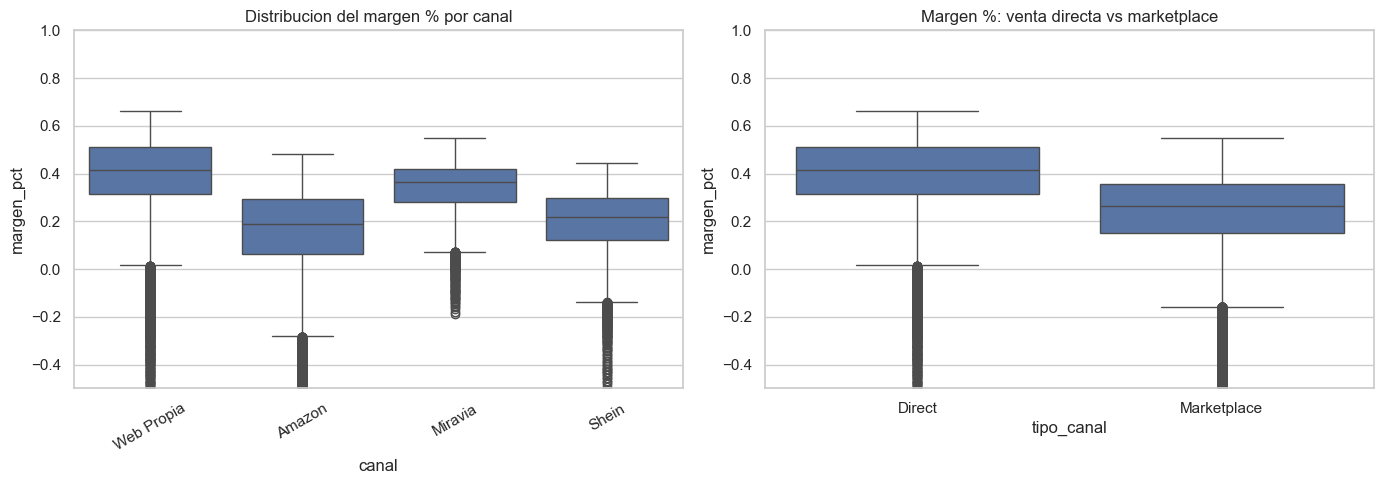

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=ventas, x="canal", y="margen_pct", ax=axes[0])
axes[0].set_title("Distribucion del margen % por canal")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylim(-0.5, 1.0)

sns.boxplot(data=ventas, x="tipo_canal", y="margen_pct", ax=axes[1])
axes[1].set_title("Margen %: venta directa vs marketplace")
axes[1].set_ylim(-0.5, 1.0)

guardar_figura("estadistica_boxplot_margen_canal.png", OUT_GRAFICOS)
plt.show()

## 3. Contraste: venta directa vs marketplace

Hipotesis de negocio:

- H0: el margen porcentual de venta directa y marketplaces no presenta diferencias relevantes.
- H1: el margen porcentual cambia segun el tipo de canal.

Usamos Mann-Whitney porque el margen por linea suele tener distribuciones asimetricas y outliers.

In [5]:
directo = ventas.loc[ventas["tipo_canal"].str.lower().eq("direct"), "margen_pct"].dropna()
marketplace = ventas.loc[ventas["tipo_canal"].str.lower().eq("marketplace"), "margen_pct"].dropna()

resultado_mw = stats.mannwhitneyu(directo, marketplace, alternative="two-sided")
contraste_directo_marketplace = pd.DataFrame(
    {
        "comparacion": ["Direct vs Marketplace"],
        "n_direct": [len(directo)],
        "n_marketplace": [len(marketplace)],
        "mediana_direct": [directo.median()],
        "mediana_marketplace": [marketplace.median()],
        "estadistico": [resultado_mw.statistic],
        "pvalor": [resultado_mw.pvalue],
        "interpretacion": [interpretar_pvalor(resultado_mw.pvalue)],
    }
)

display(contraste_directo_marketplace)
contraste_directo_marketplace.to_csv(OUT_DATOS / "estadistica_contraste_direct_marketplace.csv", index=False)

,comparacion,n_direct,n_marketplace,mediana_direct,mediana_marketplace,estadistico,pvalor,interpretacion
0,Direct vs Marketplace,18750,56250,0.4139,0.2633,"816,434,191.0000",0.0000,Diferencia estadisticamente significativa


## 4. Contraste entre canales

Ahora comprobamos si todos los canales se comportan igual o si hay diferencias globales en margen.

In [6]:
grupos_canal = [grupo["margen_pct"].dropna() for _, grupo in ventas.groupby("canal")]
resultado_kruskal = stats.kruskal(*grupos_canal)

contraste_canales = pd.DataFrame(
    {
        "test": ["Kruskal-Wallis margen_pct por canal"],
        "estadistico": [resultado_kruskal.statistic],
        "pvalor": [resultado_kruskal.pvalue],
        "interpretacion": [interpretar_pvalor(resultado_kruskal.pvalue)],
    }
)

display(contraste_canales)
contraste_canales.to_csv(OUT_DATOS / "estadistica_contraste_canales.csv", index=False)

,test,estadistico,pvalor,interpretacion
0,Kruskal-Wallis margen_pct por canal,"25,796.0985",0.0000,Diferencia estadisticamente significativa


## 5. Correlaciones economicas

Logica de negocio: queremos detectar que variables estan mas asociadas al margen para orientar acciones: descuentos, comisiones, costes logisticos o mix de producto.

,unidades_vendidas,precio_unitario_bruto,importe_descuento,descuento_pct_real,ventas_netas,coste_producto,comision,coste_pago,coste_envio_asignado,costes_totales,margen,margen_pct
unidades_vendidas,1.0000,0.0225,0.1034,-0.0410,0.6089,0.6434,0.4676,0.3785,-0.0336,0.6373,0.4822,0.1853
precio_unitario_bruto,0.0225,1.0000,0.2271,-0.0030,0.7106,0.6462,0.4700,0.3635,-0.0512,0.6389,0.6913,0.5025
importe_descuento,0.1034,0.2271,1.0000,0.7325,0.1308,0.2031,0.1559,0.0919,-0.0178,0.2019,0.0237,-0.0547
descuento_pct_real,-0.0410,-0.0030,0.7325,1.0000,-0.1113,-0.0466,-0.0577,-0.0663,0.0075,-0.0534,-0.1655,-0.2992
ventas_netas,0.6089,0.7106,0.1308,-0.1113,1.0000,0.9576,0.6869,0.5472,-0.0648,0.9452,0.9163,0.4493
coste_producto,0.6434,0.6462,0.2031,-0.0466,0.9576,1.0000,0.6886,0.5394,-0.0767,0.9783,0.7876,0.3308
comision,0.4676,0.4700,0.1559,-0.0577,0.6869,0.6886,1.0000,0.6094,0.0370,0.8167,0.4240,0.0785
coste_pago,0.3785,0.3635,0.0919,-0.0663,0.5472,0.5394,0.6094,1.0000,0.5852,0.6375,0.3538,-0.0106
coste_envio_asignado,-0.0336,-0.0512,-0.0178,0.0075,-0.0648,-0.0767,0.0370,0.5852,1.0000,0.0086,-0.1451,-0.3767
costes_totales,0.6373,0.6389,0.2019,-0.0534,0.9452,0.9783,0.8167,0.6375,0.0086,1.0000,0.7353,0.2661


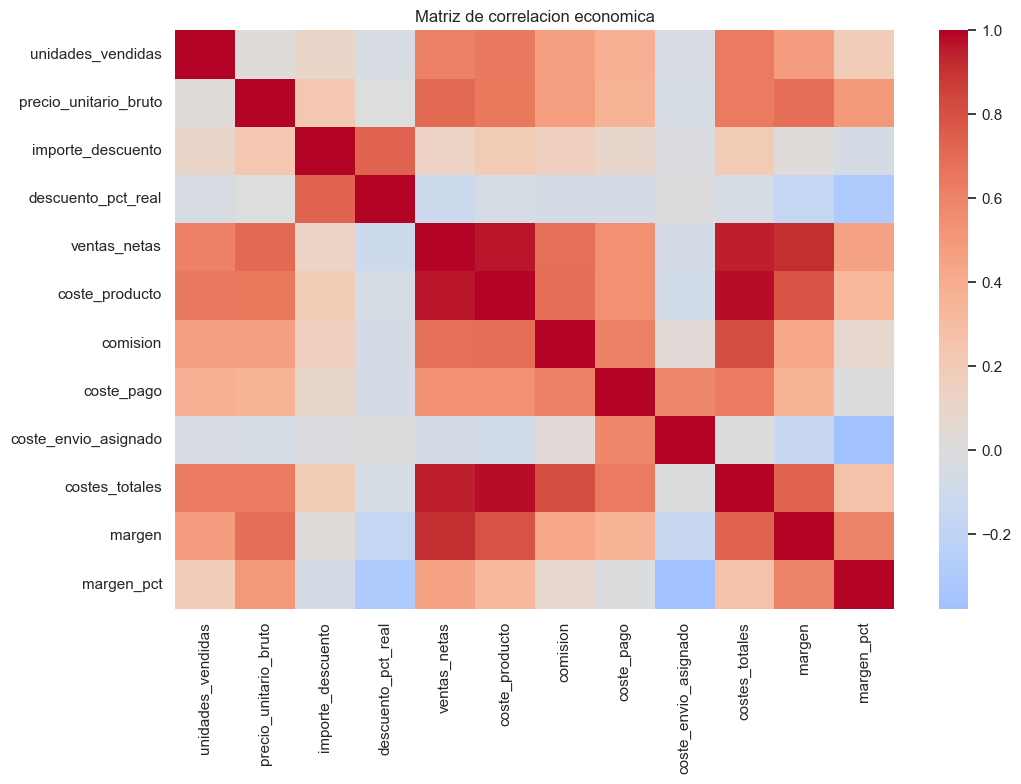

In [7]:
columnas_corr = [
    "unidades_vendidas",
    "precio_unitario_bruto",
    "importe_descuento",
    "descuento_pct_real",
    "ventas_netas",
    "coste_producto",
    "comision",
    "coste_pago",
    "coste_envio_asignado",
    "costes_totales",
    "margen",
    "margen_pct",
]

corr = matriz_correlacion(ventas, columnas_corr)
display(corr)
corr.to_csv(OUT_DATOS / "estadistica_correlaciones.csv")

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matriz de correlacion economica")
guardar_figura("estadistica_correlaciones_heatmap.png", OUT_GRAFICOS)
plt.show()

## 6. Outliers de margen

Los outliers no se eliminan automaticamente: en negocio pueden representar errores, promociones agresivas o productos que requieren una decision.

In [8]:
ventas_outliers = detectar_outliers_iqr(ventas, "margen_pct")
resumen_outliers = (
    ventas_outliers.groupby("canal", as_index=False)
    .agg(
        lineas=("id_linea_venta", "count"),
        outliers_margen=("margen_pct_outlier_iqr", "sum"),
        margen_medio=("margen_pct", "mean"),
    )
)
resumen_outliers["pct_outliers"] = resumen_outliers["outliers_margen"] / resumen_outliers["lineas"]

display(resumen_outliers.sort_values("pct_outliers", ascending=False))
resumen_outliers.to_csv(OUT_DATOS / "estadistica_outliers_margen_por_canal.csv", index=False)

,canal,lineas,outliers_margen,margen_medio,pct_outliers
0,Amazon,18750,1905,0.1486,0.1016
2,Shein,18750,412,0.1984,0.0220
3,Web Propia,18750,339,0.3936,0.0181
1,Miravia,18750,5,0.3499,0.0003


## 7. Modelo estadistico explicativo

Este no es el modelo predictivo final. Es un modelo interpretable para explicar que factores se asocian al margen %.

Sirve para la memoria porque traduce la base de datos en una explicacion de negocio.

In [9]:
muestra_modelo = ventas[[
    "margen_pct",
    "descuento_pct_real",
    "peso_comision_sobre_venta",
    "peso_envio_sobre_venta",
    "peso_coste_producto_sobre_venta",
    "unidades_vendidas",
    "canal",
    "categoria",
]].dropna().sample(n=min(20000, len(ventas)), random_state=42)

formula = (
    "margen_pct ~ descuento_pct_real + peso_comision_sobre_venta + "
    "peso_envio_sobre_venta + peso_coste_producto_sobre_venta + "
    "unidades_vendidas + C(canal) + C(categoria)"
)
modelo_ols = smf.ols(formula=formula, data=muestra_modelo).fit()

print(modelo_ols.summary())

coeficientes = modelo_ols.params.reset_index()
coeficientes.columns = ["variable", "coeficiente"]
coeficientes.to_csv(OUT_DATOS / "estadistica_modelo_explicativo_coeficientes.csv", index=False)

                            OLS Regression Results                            
Dep. Variable:             margen_pct   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 5.456e+05
Date:                Thu, 11 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:37:41   Log-Likelihood:                 66025.
No. Observations:               20000   AIC:                        -1.320e+05
Df Residuals:                   19982   BIC:                        -1.319e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

## 8. Evolucion temporal

Esta parte prepara el terreno para prediccion: si hay tendencia o estacionalidad, tiene sentido usar variables temporales en ML.

,periodo,ventas_netas,margen,unidades,margen_pct,ventas_media_3m
0,2024-01-01,"255,074.6500","87,821.6800",4676,0.3443,"255,074.6500"
1,2024-02-01,"241,786.5300","84,495.2100",4377,0.3495,"248,430.5900"
2,2024-03-01,"257,018.5900","88,779.2900",4678,0.3454,"251,293.2567"
3,2024-04-01,"250,879.6100","87,922.7600",4524,0.3505,"249,894.9100"
4,2024-05-01,"256,225.0700","88,988.6100",4671,0.3473,"254,707.7567"
5,2024-06-01,"249,165.3900","86,486.8300",4519,0.3471,"252,090.0233"
6,2024-07-01,"253,982.7900","88,804.5900",4676,0.3496,"253,124.4167"
7,2024-08-01,"257,916.5800","89,129.6100",4670,0.3456,"253,688.2533"
8,2024-09-01,"248,786.7700","88,642.8100",4521,0.3563,"253,562.0467"
9,2024-10-01,"255,601.5500","87,978.3100",4675,0.3442,"254,101.6333"


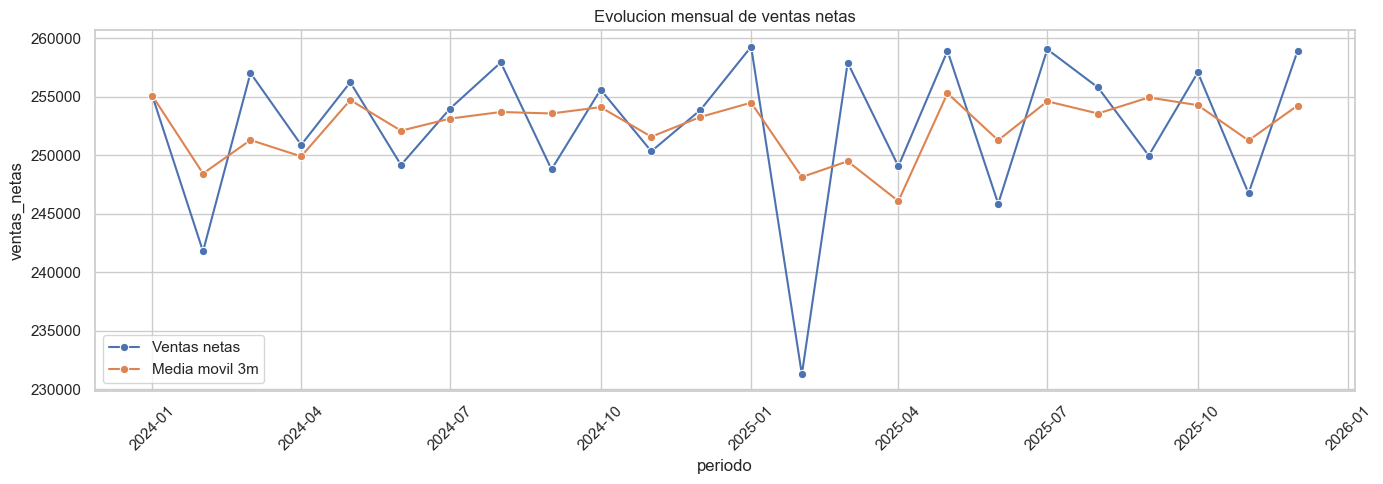

In [10]:
serie_mensual = (
    ventas.assign(periodo=ventas["fecha"].dt.to_period("M").dt.to_timestamp())
    .groupby("periodo", as_index=False)
    .agg(
        ventas_netas=("ventas_netas", "sum"),
        margen=("margen", "sum"),
        unidades=("unidades_vendidas", "sum"),
    )
)
serie_mensual["margen_pct"] = serie_mensual["margen"] / serie_mensual["ventas_netas"]
serie_mensual["ventas_media_3m"] = serie_mensual["ventas_netas"].rolling(3, min_periods=1).mean()

display(serie_mensual)
serie_mensual.to_csv(OUT_DATOS / "estadistica_serie_mensual.csv", index=False)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=serie_mensual, x="periodo", y="ventas_netas", marker="o", label="Ventas netas", ax=ax)
sns.lineplot(data=serie_mensual, x="periodo", y="ventas_media_3m", marker="o", label="Media movil 3m", ax=ax)
ax.set_title("Evolucion mensual de ventas netas")
ax.tick_params(axis="x", rotation=45)
guardar_figura("estadistica_evolucion_mensual.png", OUT_GRAFICOS)
plt.show()

## 9. Conclusiones para la memoria

Despues de ejecutar, completar con resultados concretos:

- Que canal deja mayor margen relativo y cual genera mas volumen.
- Si marketplace tiene una diferencia estadistica frente a venta directa.
- Que costes pesan mas sobre la rentabilidad.
- Que outliers merecen revision de precio, descuento o coste.
- Que patrones temporales justifican pasar a machine learning.

# Parte B - Machine Learning: prediccion de ventas

Objetivo: predecir unidades vendidas por dia, canal y categoria para anticipar demanda y conectar despues con stock, promociones y Power BI.

## 1. Dataset de prediccion

Usamos la vista `vw_prediccion_base_ventas`, que ya agrega ventas diarias por canal y categoria e incluye medias moviles.

Objetivo a predecir: `unidades_vendidas`.

Nota metodologica: las medias moviles que vienen de SQL se cargan para comparacion, pero no se usan como predictor directo si incluyen el dia actual. Para evitar fuga de informacion, el modelo usa lags y medias moviles desplazadas calculadas en Python.


In [11]:
df = read_sql("SELECT * FROM silver.prediccion_base_ventas")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["canal", "categoria", "fecha"]).reset_index(drop=True)

print(df.shape)
display(df.head())

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


(26469, 14)


,fecha,anio,mes_numero,dia_semana,es_fin_de_semana,canal,categoria,unidades_vendidas,ventas_netas,margen_total,media_movil_7d_unidades,media_movil_30d_unidades,prediccion_naive_proximo_dia,tendencia_ventas
0,2024-01-01,2024,1,1,False,Amazon,Accesorios,4,106.3200,14.0100,NaN,NaN,NaN,Sin historico
1,2024-01-02,2024,1,2,False,Amazon,Accesorios,6,297.1800,65.7000,4.0000,4.0000,4.0000,Tendencia estable
2,2024-01-03,2024,1,3,False,Amazon,Accesorios,6,297.1800,65.7000,5.0000,5.0000,5.0000,Tendencia estable
3,2024-01-04,2024,1,4,False,Amazon,Accesorios,7,360.3800,79.8300,5.3333,5.3333,5.3333,Tendencia estable
4,2024-01-05,2024,1,5,False,Amazon,Accesorios,7,360.3800,79.8300,5.7500,5.7500,5.7500,Tendencia estable


## 2. Feature engineering

Creamos variables temporales y retardos.

Ejemplo de logica: las ventas de ayer, de la semana pasada y la media movil de 7/30 dias suelen explicar parte de la demanda futura.

In [12]:
df_features = crear_features_temporales(df, "fecha")
df_features = crear_lags_por_grupo(
    df_features,
    grupo_cols=["canal", "categoria"],
    objetivo="unidades_vendidas",
    lags=[1, 7, 14, 30],
    ventanas=[7, 14, 30],
)

# Eliminamos filas sin historico suficiente para lags.
df_modelo = df_features.dropna().copy()

print(df_modelo.shape)
display(df_modelo.head())
df_modelo.to_csv(OUT_DATOS / "dataset_ml_ventas.csv", index=False)

(25269, 26)


,fecha,anio,mes_numero,dia_semana,es_fin_de_semana,canal,categoria,unidades_vendidas,ventas_netas,margen_total,media_movil_7d_unidades,media_movil_30d_unidades,prediccion_naive_proximo_dia,tendencia_ventas,dia_mes,semana_anio,mes,trimestre,dias_desde_inicio,unidades_vendidas_lag_1,unidades_vendidas_lag_7,unidades_vendidas_lag_14,unidades_vendidas_lag_30,unidades_vendidas_media_7,unidades_vendidas_media_14,unidades_vendidas_media_30
30,2024-02-03,2024,2,6,1,Amazon,Accesorios,2,147.7000,51.7700,1.0000,2.9333,1.0000,Tendencia decreciente,3,5,2,1,33,1.0000,1.0000,2.0000,4.0000,1.0000,1.4286,2.9333
31,2024-02-04,2024,2,7,1,Amazon,Accesorios,2,147.7000,51.7700,1.1429,2.8667,1.1429,Tendencia decreciente,4,5,2,1,34,2.0000,1.0000,2.0000,6.0000,1.1429,1.4286,2.8667
32,2024-02-05,2024,2,1,0,Amazon,Accesorios,2,147.7000,51.7700,1.2857,2.7333,1.2857,Tendencia decreciente,5,6,2,1,35,2.0000,1.0000,2.0000,6.0000,1.2857,1.4286,2.7333
33,2024-02-06,2024,2,2,0,Amazon,Accesorios,4,224.6600,79.8800,1.4286,2.6000,1.4286,Tendencia decreciente,6,6,2,1,36,2.0000,1.0000,2.0000,7.0000,1.4286,1.4286,2.6000
34,2024-02-07,2024,2,3,0,Amazon,Accesorios,4,224.6600,79.8800,1.8571,2.5000,1.8571,Tendencia decreciente,7,6,2,1,37,4.0000,1.0000,2.0000,7.0000,1.8571,1.5714,2.5000


## 3. Train/test temporal

No mezclamos aleatoriamente porque seria hacer trampa temporal. Entrenamos con el pasado y validamos con fechas posteriores.

In [13]:
train, test = train_test_temporal(df_modelo, "fecha", test_ratio=0.2)

objetivo = "unidades_vendidas"
features_numericas = [
    "anio",
    "mes_numero",
    "dia_semana",
    "es_fin_de_semana",
    "dias_desde_inicio",
    "unidades_vendidas_lag_1",
    "unidades_vendidas_lag_7",
    "unidades_vendidas_lag_14",
    "unidades_vendidas_lag_30",
    "unidades_vendidas_media_7",
    "unidades_vendidas_media_14",
    "unidades_vendidas_media_30",
]
features_categoricas = ["canal", "categoria"]
features = features_numericas + features_categoricas

X_train = train[features]
y_train = train[objetivo]
X_test = test[features]
y_test = test[objetivo]

print("train", train["fecha"].min(), train["fecha"].max(), X_train.shape)
print("test", test["fecha"].min(), test["fecha"].max(), X_test.shape)

train 2024-01-31 00:00:00 2025-08-12 00:00:00 (20166, 14)
test 2025-08-13 00:00:00 2025-12-31 00:00:00 (5103, 14)


## 4. Baseline simple

Antes de usar ML, probamos una prediccion sencilla: la media movil de 7 dias. Si un modelo complejo no mejora esto, no aporta valor.

In [14]:
baseline_pred = test["media_movil_7d_unidades"].astype(float).values
metricas = []
metricas.append({"modelo": "Baseline media movil 7d", **metricas_regresion(y_test, baseline_pred)})

resultados_pred = [
    preparar_resultados_prediccion(
        test[["fecha", "canal", "categoria"]],
        y_test,
        baseline_pred,
        "Baseline media movil 7d",
    )
]

pd.DataFrame(metricas)

,modelo,MAE,RMSE,MAPE,WMAPE,R2,Sesgo_pct
0,Baseline media movil 7d,1.2575,1.6599,41.2064,30.1586,0.5504,0.0846


## 5. Modelos de machine learning

Probamos modelos interpretables/robustos:

- Regresion lineal: referencia simple.
- Ridge: lineal con regularizacion.
- Random Forest: captura relaciones no lineales.
- Gradient Boosting: suele funcionar bien en datos tabulares.

In [15]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
    ]
)

modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1, min_samples_leaf=3),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

modelos_entrenados = {}

for nombre, estimador in modelos.items():
    pipeline = Pipeline([("preprocesador", preprocesador), ("modelo", estimador)])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    pred = np.clip(pred, 0, None)

    modelos_entrenados[nombre] = pipeline
    metricas.append({"modelo": nombre, **metricas_regresion(y_test, pred)})
    resultados_pred.append(
        preparar_resultados_prediccion(
            test[["fecha", "canal", "categoria"]],
            y_test,
            pred,
            nombre,
        )
    )

metricas_ml = pd.DataFrame(metricas).sort_values("RMSE")
display(metricas_ml)
metricas_ml.to_csv(OUT_DATOS / "metricas_ml_ventas.csv", index=False)

predicciones_ml = pd.concat(resultados_pred, ignore_index=True)
predicciones_ml.to_csv(OUT_DATOS / "predicciones_ml_ventas.csv", index=False)

,modelo,MAE,RMSE,MAPE,WMAPE,R2,Sesgo_pct
3,Random Forest,0.3003,0.4961,9.8459,7.2013,0.9598,-0.3991
4,Gradient Boosting,0.6126,0.9468,20.6629,14.6918,0.8537,-0.0025
1,Linear Regression,0.6501,0.9941,20.7694,15.5904,0.8387,0.1136
2,Ridge,0.6500,0.9941,20.7692,15.5894,0.8387,0.1133
0,Baseline media movil 7d,1.2575,1.6599,41.2064,30.1586,0.5504,0.0846


## 6. Comparacion visual del mejor modelo

Agregamos por fecha para ver si el modelo acompana la tendencia general.

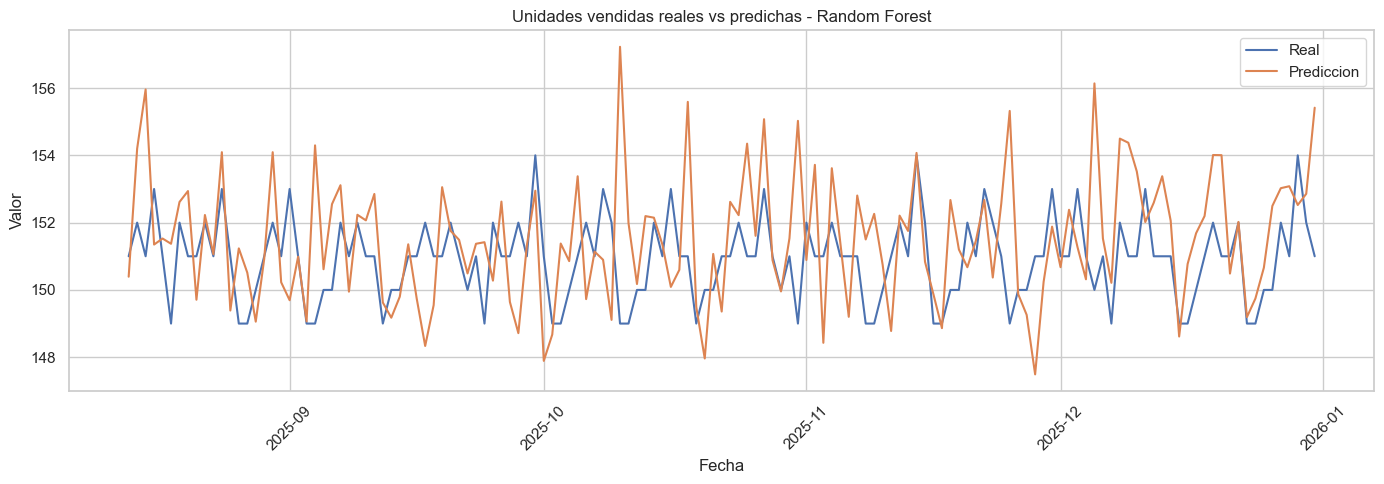

Mejor modelo: Random Forest


In [16]:
mejor_modelo = metricas_ml.iloc[0]["modelo"]
mejores_predicciones = predicciones_ml[predicciones_ml["modelo"] == mejor_modelo].copy()
serie_pred = mejores_predicciones.groupby("fecha", as_index=False).agg(real=("real", "sum"), prediccion=("prediccion", "sum"))

fig, ax = grafico_real_vs_predicho(
    serie_pred,
    titulo=f"Unidades vendidas reales vs predichas - {mejor_modelo}",
)
guardar_figura("ml_real_vs_predicho_mejor_modelo.png", OUT_GRAFICOS)
plt.show()

print("Mejor modelo:", mejor_modelo)

## 7. Importancia de variables

Si el mejor modelo es de arboles, podemos ver que variables pesan mas. Esto ayuda a explicar el modelo sin convertirlo en caja negra.

,variable,importancia
5,num__unidades_vendidas_lag_1,0.8456
11,num__unidades_vendidas_media_30,0.0271
10,num__unidades_vendidas_media_14,0.0259
9,num__unidades_vendidas_media_7,0.0212
8,num__unidades_vendidas_lag_30,0.0153
7,num__unidades_vendidas_lag_14,0.0134
6,num__unidades_vendidas_lag_7,0.0098
2,num__dia_semana,0.0049
4,num__dias_desde_inicio,0.0035
21,cat__categoria_Hogar,0.0033


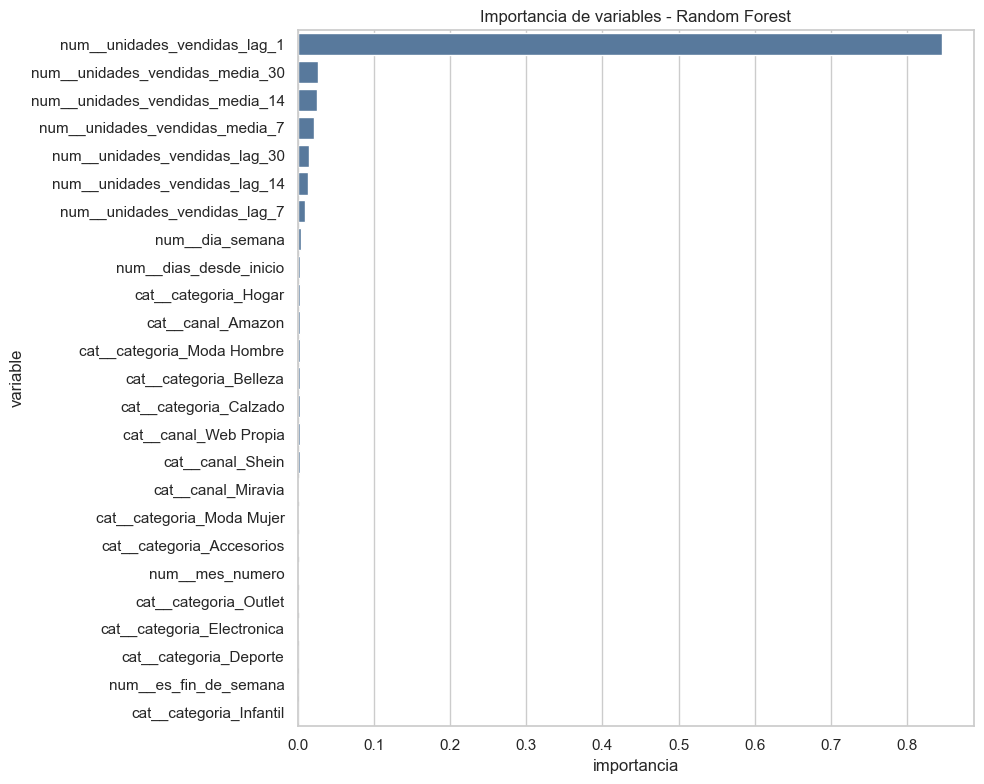

In [17]:
modelo_arbol = modelos_entrenados.get(mejor_modelo)

try:
    estimador = modelo_arbol.named_steps["modelo"]
    if hasattr(estimador, "feature_importances_"):
        nombres_features = modelo_arbol.named_steps["preprocesador"].get_feature_names_out()
        importancias = pd.DataFrame({"variable": nombres_features, "importancia": estimador.feature_importances_})
        importancias = importancias.sort_values("importancia", ascending=False).head(25)
        display(importancias)
        importancias.to_csv(OUT_DATOS / "ml_importancia_variables.csv", index=False)

        plt.figure(figsize=(10, 8))
        sns.barplot(data=importancias, x="importancia", y="variable", color="#4C78A8")
        plt.title(f"Importancia de variables - {mejor_modelo}")
        guardar_figura("ml_importancia_variables.png", OUT_GRAFICOS)
        plt.show()
    else:
        print("El mejor modelo no tiene feature_importances_.")
except Exception as exc:
    print("No se pudo calcular importancia de variables:", exc)

## 8. Predicciones para Power BI

Dejamos un CSV con predicciones por fecha, canal y categoria. Mas adelante se podra cargar en Power BI o escribir de vuelta a SQL Server.

In [18]:
display(predicciones_ml.head())
print(OUT_DATOS / "predicciones_ml_ventas.csv")

,fecha,canal,categoria,modelo,real,prediccion,error,error_abs
0,2025-08-13,Shein,Hogar,Baseline media movil 7d,3.0000,4.8571,-1.8571,1.8571
1,2025-08-13,Shein,Calzado,Baseline media movil 7d,5.0000,5.1429,-0.1429,0.1429
2,2025-08-13,Web Propia,Outlet,Baseline media movil 7d,1.0000,1.0000,0.0000,0.0000
3,2025-08-13,Shein,Belleza,Baseline media movil 7d,7.0000,6.5714,0.4286,0.4286
4,2025-08-13,Miravia,Belleza,Baseline media movil 7d,1.0000,1.2857,-0.2857,0.2857


G:\TFM_FINAL_VERSION_2\outputs\datos\predicciones_ml_ventas.csv


## 9. Conclusion para la memoria

Despues de ejecutar, documentar:

- Cual es el baseline y por que era necesario.
- Que modelo mejora mas las metricas.
- Si el error es aceptable para planificacion de stock/promociones.
- Que variables explican mas la prediccion.
- Como se usarian estas predicciones en el dashboard final.

# Parte C - Deep Learning opcional

Objetivo: probar si una red neuronal sencilla mejora de verdad a los modelos clasicos. Si no mejora, la conclusion tambien es valiosa: para este problema conviene un modelo mas interpretable.

## 1. Preparacion del dataset

Usamos exactamente el mismo dataset que en ML para comparar de forma justa.

In [19]:
df = read_sql("SELECT * FROM silver.prediccion_base_ventas")
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values(["canal", "categoria", "fecha"]).reset_index(drop=True)

df_features = crear_features_temporales(df, "fecha")
df_features = crear_lags_por_grupo(
    df_features,
    grupo_cols=["canal", "categoria"],
    objetivo="unidades_vendidas",
    lags=[1, 7, 14, 30],
    ventanas=[7, 14, 30],
)
df_modelo = df_features.dropna().copy()

train, test = train_test_temporal(df_modelo, "fecha", test_ratio=0.2)

objetivo = "unidades_vendidas"
features_numericas = [
    "anio",
    "mes_numero",
    "dia_semana",
    "es_fin_de_semana",
    "dias_desde_inicio",
    "unidades_vendidas_lag_1",
    "unidades_vendidas_lag_7",
    "unidades_vendidas_lag_14",
    "unidades_vendidas_lag_30",
    "unidades_vendidas_media_7",
    "unidades_vendidas_media_14",
    "unidades_vendidas_media_30",
]
features_categoricas = ["canal", "categoria"]
features = features_numericas + features_categoricas

X_train = train[features]
y_train = train[objetivo]
X_test = test[features]
y_test = test[objetivo]

print(X_train.shape, X_test.shape)

G:\TFM_FINAL_VERSION_2\src\conexion_sql.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(query, conn)


(20166, 14) (5103, 14)


## 2. Red neuronal MLP

La red tiene varias capas ocultas. Activamos `early_stopping` para detener entrenamiento si no mejora, reduciendo sobreajuste.

In [20]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), features_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), features_categoricas),
    ]
)

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    batch_size=128,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=42,
)

modelo_dl = Pipeline([("preprocesador", preprocesador), ("modelo", mlp)])
modelo_dl.fit(X_train, y_train)

pred_dl = np.clip(modelo_dl.predict(X_test), 0, None)
metricas_dl = pd.DataFrame([{ "modelo": "MLP Neural Network", **metricas_regresion(y_test, pred_dl)}])
display(metricas_dl)
metricas_dl.to_csv(OUT_DATOS / "metricas_deep_learning_mlp.csv", index=False)

predicciones_dl = preparar_resultados_prediccion(test[["fecha", "canal", "categoria"]], y_test, pred_dl, "MLP Neural Network")
predicciones_dl.to_csv(OUT_DATOS / "predicciones_deep_learning_mlp.csv", index=False)

,modelo,MAE,RMSE,MAPE,WMAPE,R2,Sesgo_pct
0,MLP Neural Network,0.5272,0.7527,17.3865,12.6425,0.9075,-1.8879


## 3. Comparacion con machine learning clasico

Si ya se ejecuto el notebook 03, cargamos sus metricas para comparar.

In [21]:
ruta_metricas_ml = OUT_DATOS / "metricas_ml_ventas.csv"

if ruta_metricas_ml.exists():
    metricas_ml = pd.read_csv(ruta_metricas_ml)
    comparacion = pd.concat([metricas_ml, metricas_dl], ignore_index=True).sort_values("RMSE")
else:
    comparacion = metricas_dl.copy()

display(comparacion)
comparacion.to_csv(OUT_DATOS / "comparacion_ml_deep_learning.csv", index=False)

,modelo,MAE,RMSE,MAPE,WMAPE,R2,Sesgo_pct
0,Random Forest,0.3003,0.4961,9.8459,7.2013,0.9598,-0.3991
5,MLP Neural Network,0.5272,0.7527,17.3865,12.6425,0.9075,-1.8879
1,Gradient Boosting,0.6126,0.9468,20.6629,14.6918,0.8537,-0.0025
2,Linear Regression,0.6501,0.9941,20.7694,15.5904,0.8387,0.1136
3,Ridge,0.6500,0.9941,20.7692,15.5894,0.8387,0.1133
4,Baseline media movil 7d,1.2575,1.6599,41.2064,30.1586,0.5504,0.0846


## 4. Grafico real vs predicho

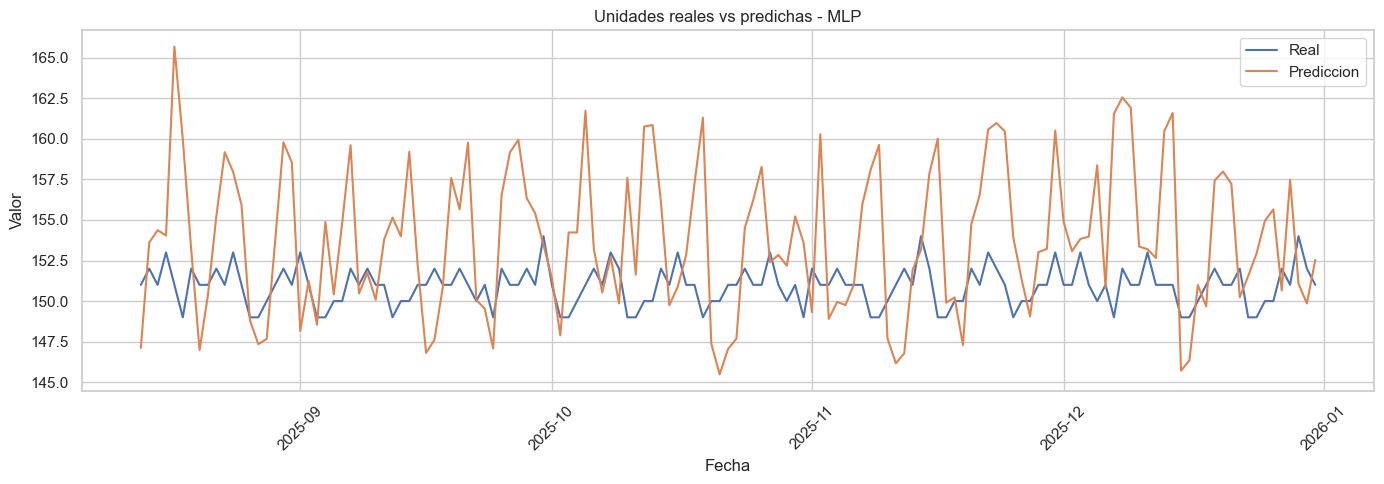

In [22]:
serie_pred_dl = predicciones_dl.groupby("fecha", as_index=False).agg(real=("real", "sum"), prediccion=("prediccion", "sum"))
fig, ax = grafico_real_vs_predicho(serie_pred_dl, titulo="Unidades reales vs predichas - MLP")
guardar_figura("deep_learning_mlp_real_vs_predicho.png", OUT_GRAFICOS)
plt.show()

## 5. Curva de entrenamiento

Sirve para explicar si la red aprendio o si se quedo estancada.

,iteracion,loss
120,121,0.1588
121,122,0.1610
122,123,0.1565
123,124,0.1568
124,125,0.1572


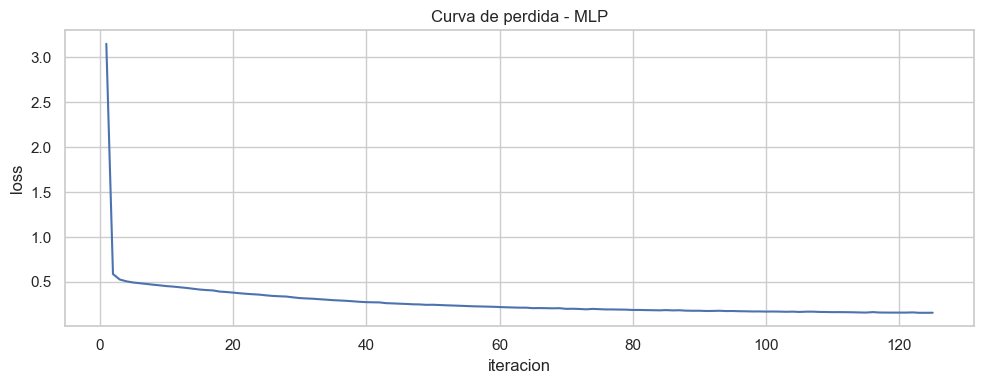

In [23]:
loss_curve = pd.DataFrame({"iteracion": range(1, len(modelo_dl.named_steps["modelo"].loss_curve_) + 1), "loss": modelo_dl.named_steps["modelo"].loss_curve_})
display(loss_curve.tail())

plt.figure(figsize=(10, 4))
sns.lineplot(data=loss_curve, x="iteracion", y="loss")
plt.title("Curva de perdida - MLP")
guardar_figura("deep_learning_mlp_loss_curve.png", OUT_GRAFICOS)
plt.show()

## 6. Decision de negocio

Completar despues de ejecutar:

- Si la red neuronal mejora claramente al mejor modelo clasico, se puede defender como aporte avanzado.
- Si no mejora, se defiende que el problema se resuelve mejor con modelos tabulares interpretables.
- En ambos casos, el valor de negocio esta en anticipar demanda para stock, promociones y margen.

# Cierre del notebook

Al terminar la ejecucion, este notebook deberia dejar generados:

- tablas de estadistica y contrastes en outputs/datos;
- metricas de modelos ML y DL;
- predicciones exportadas para futura carga en Power BI;
- graficos en outputs/graficos;
- argumentos de negocio para explicar por que se usa cada tecnica.

# Parte D - Validacion final del modelo predictivo

Esta seccion cierra el bloque de Python desde una perspectiva de negocio. No basta con entrenar modelos: se compara contra un baseline, se mide la mejora, se comprueba el sesgo y se decide si el modelo es util para planificacion.

In [24]:
metricas_validacion = pd.read_csv(OUT_DATOS / "comparacion_ml_deep_learning.csv")
prediction_files = [
    OUT_DATOS / "predicciones_ml_ventas.csv",
    OUT_DATOS / "predicciones_deep_learning_mlp.csv",
]
predicciones_validacion = pd.concat(
    [pd.read_csv(path, parse_dates=["fecha"]) for path in prediction_files if path.exists()],
    ignore_index=True,
)

for col in ["MAE", "RMSE", "MAPE", "R2"]:
    metricas_validacion[col] = pd.to_numeric(metricas_validacion[col], errors="coerce")

resumen_error = (
    predicciones_validacion.assign(
        real=lambda d: pd.to_numeric(d["real"], errors="coerce"),
        prediccion=lambda d: pd.to_numeric(d["prediccion"], errors="coerce"),
        error=lambda d: pd.to_numeric(d["error"], errors="coerce"),
        error_abs=lambda d: pd.to_numeric(d["error_abs"], errors="coerce"),
    )
    .groupby("modelo", as_index=False)
    .agg(
        filas_validacion=("fecha", "size"),
        real_total=("real", "sum"),
        prediccion_total=("prediccion", "sum"),
        error_abs_total=("error_abs", "sum"),
        error_total=("error", "sum"),
    )
)
resumen_error["WMAPE"] = resumen_error["error_abs_total"] / resumen_error["real_total"] * 100
resumen_error["Sesgo_pct"] = resumen_error["error_total"] / resumen_error["real_total"] * 100

metricas_validacion = metricas_validacion.merge(
    resumen_error[["modelo", "filas_validacion", "real_total", "prediccion_total", "WMAPE", "Sesgo_pct"]],
    on="modelo",
    how="left",
)
metricas_validacion = metricas_validacion.sort_values(["RMSE", "MAE"]).reset_index(drop=True)

baseline = metricas_validacion.loc[metricas_validacion["modelo"].eq("Baseline media movil 7d")].iloc[0]
metricas_validacion["mejora_rmse_vs_baseline_pct"] = (
    (baseline["RMSE"] - metricas_validacion["RMSE"]) / baseline["RMSE"] * 100
)
metricas_validacion["mejora_mae_vs_baseline_pct"] = (
    (baseline["MAE"] - metricas_validacion["MAE"]) / baseline["MAE"] * 100
)
metricas_validacion["decision"] = np.where(
    metricas_validacion.index == 0,
    "Modelo seleccionado",
    "Modelo comparativo",
)

display(metricas_validacion)
metricas_validacion.to_csv(OUT_DATOS / "validacion_modelo_predictivo.csv", index=False)

,modelo,MAE,RMSE,MAPE,WMAPE_x,R2,Sesgo_pct_x,filas_validacion,real_total,prediccion_total,WMAPE_y,Sesgo_pct_y,mejora_rmse_vs_baseline_pct,mejora_mae_vs_baseline_pct,decision
0,Random Forest,0.3003,0.4961,9.8459,7.2013,0.9598,-0.3991,5103,"21,278.0000","21,362.9305",7.2013,-0.3991,70.1100,76.1220,Modelo seleccionado
1,MLP Neural Network,0.5272,0.7527,17.3865,12.6425,0.9075,-1.8879,5103,"21,278.0000","21,679.7171",12.6425,-1.8879,54.6521,58.0799,Modelo comparativo
2,Gradient Boosting,0.6126,0.9468,20.6629,14.6918,0.8537,-0.0025,5103,"21,278.0000","21,278.5417",14.6918,-0.0025,42.9609,51.2850,Modelo comparativo
3,Linear Regression,0.6501,0.9941,20.7694,15.5904,0.8387,0.1136,5103,"21,278.0000","21,253.8359",15.5904,0.1136,40.1092,48.3053,Modelo comparativo
4,Ridge,0.6500,0.9941,20.7692,15.5894,0.8387,0.1133,5103,"21,278.0000","21,253.9009",15.5894,0.1133,40.1089,48.3087,Modelo comparativo
5,Baseline media movil 7d,1.2575,1.6599,41.2064,30.1586,0.5504,0.0846,5103,"21,278.0000","21,259.9979",30.1586,0.0846,0.0000,0.0000,Modelo comparativo


In [25]:
mejor_modelo_validado = metricas_validacion.iloc[0]["modelo"]
pred_mejor = predicciones_validacion[predicciones_validacion["modelo"].eq(mejor_modelo_validado)].copy()
for col in ["real", "prediccion", "error", "error_abs"]:
    pred_mejor[col] = pd.to_numeric(pred_mejor[col], errors="coerce")

validacion_canal = (
    pred_mejor.groupby("canal", as_index=False)
    .agg(
        filas=("fecha", "size"),
        real_total=("real", "sum"),
        prediccion_total=("prediccion", "sum"),
        mae=("error_abs", "mean"),
        error_abs_total=("error_abs", "sum"),
        error_total=("error", "sum"),
    )
    .sort_values("mae", ascending=False)
)
validacion_canal["wmape"] = validacion_canal["error_abs_total"] / validacion_canal["real_total"] * 100
validacion_canal["sesgo_pct"] = validacion_canal["error_total"] / validacion_canal["real_total"] * 100

validacion_categoria = (
    pred_mejor.groupby("categoria", as_index=False)
    .agg(
        filas=("fecha", "size"),
        real_total=("real", "sum"),
        prediccion_total=("prediccion", "sum"),
        mae=("error_abs", "mean"),
        error_abs_total=("error_abs", "sum"),
        error_total=("error", "sum"),
    )
    .sort_values("mae", ascending=False)
)
validacion_categoria["wmape"] = validacion_categoria["error_abs_total"] / validacion_categoria["real_total"] * 100
validacion_categoria["sesgo_pct"] = validacion_categoria["error_total"] / validacion_categoria["real_total"] * 100

display(validacion_canal)
display(validacion_categoria.head(10))
validacion_canal.to_csv(OUT_DATOS / "validacion_modelo_por_canal.csv", index=False)
validacion_categoria.to_csv(OUT_DATOS / "validacion_modelo_por_categoria.csv", index=False)

,canal,filas,real_total,prediccion_total,mae,error_abs_total,error_total,wmape,sesgo_pct
3,Web Propia,1250,"5,211.0000","5,246.5480",0.3088,385.9773,-35.5480,7.4070,-0.6822
2,Shein,1298,"5,356.0000","5,384.6368",0.3070,398.4732,-28.6368,7.4398,-0.5347
1,Miravia,1259,"5,354.0000","5,354.5047",0.3057,384.8302,-0.5047,7.1877,-0.0094
0,Amazon,1296,"5,357.0000","5,377.2410",0.2801,363.0052,-20.2410,6.7763,-0.3778


,categoria,filas,real_total,prediccion_total,mae,error_abs_total,error_total,wmape,sesgo_pct
0,Accesorios,552,"2,869.0000","2,862.0405",0.3724,205.5560,6.9595,7.1647,0.2426
2,Calzado,542,"2,801.0000","2,793.7094",0.3411,184.8586,7.2906,6.5997,0.2603
7,Moda Hombre,561,"2,766.0000","2,769.9154",0.3322,186.3511,-3.9154,6.7372,-0.1416
9,Outlet,545,"1,989.0000","2,010.5856",0.3222,175.5799,-21.5856,8.8275,-1.0853
5,Hogar,530,"2,665.0000","2,681.3494",0.3162,167.5614,-16.3494,6.2875,-0.6135
1,Belleza,564,"2,424.0000","2,427.4463",0.3124,176.2193,-3.4463,7.2698,-0.1422
8,Moda Mujer,548,"2,361.0000","2,376.7938",0.3002,164.5006,-15.7938,6.9674,-0.6689
4,Electronica,416,"1,331.0000","1,346.0274",0.2618,108.8949,-15.0274,8.1814,-1.1290
3,Deporte,434,"1,194.0000","1,211.8122",0.2090,90.7237,-17.8122,7.5983,-1.4918
6,Infantil,411,878.0000,883.2505,0.1753,72.0403,-5.2505,8.2050,-0.5980


## Decision final

El modelo se considera util si mejora al baseline temporal y mantiene un sesgo agregado bajo. Para la defensa del TFM, la lectura correcta no es "predigo cada venta exacta", sino "uso el historico para anticipar demanda por canal y categoria y alimentar decisiones de stock y planificacion".

Si la red neuronal no mejora claramente a modelos clasicos, se deja como comparacion tecnica y no como solucion final. Esta decision es profesional: en un entorno de empresa se prioriza un modelo interpretable, mantenible y suficientemente bueno.